In [1]:
!pip install -q vaderSentiment transformers torch datasets accelerate scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.0 MB/s eta 0:00:00


## Section 1 — Load & EDA

In [2]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Load từ Google Sheets
SHEET_ID = '1KXcA0PPOpygla1inEfnTc10FND6DFNL8p8vpQKAX6Tw'
url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv'
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nDtypes:\n{df.dtypes}')
df.head(5)

Shape: (4000, 6)

Columns: ['parent_asin', 'sentence_id', 'sentence_text', 'rating', 'triplets', 'category_name']

Dtypes:
parent_asin       object
sentence_id        int64
sentence_text     object
rating           float64
triplets          object
category_name     object
dtype: object


,parent_asin,sentence_id,sentence_text,rating,triplets,category_name
0,B07DGRVTWF,3,basically a poor implementation of the alexa p...,2.0,"[[""alexa platform"", ""poor implementation"", 0]]",electronics_p2
1,B07BFPJ6VX,4,support through direct messaging was great no ...,5.0,"[[""support through direct messaging"", ""great"",...",electronics_p2
2,B0B1PYNH8X,1,for echo show 5 i have the 2nd generation echo...,5.0,[],electronics_p2
3,B0007X9JMA,4,br br note i ve only used it for regular compu...,5.0,[],electronics_p2
4,B00N63V39K,6,wanted to use for business but i m in sales an...,1.0,[],electronics_p2


In [3]:
# Loại bỏ tag [GENERIC_NOUN], <br>, br br, và dọn khoảng trắng
def clean_text(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'\[GENERIC_NOUN\]', '', text)
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'\bbr\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['sentence_text'] = df['sentence_text'].apply(clean_text)
df[['sentence_text']].head(10)

,sentence_text
0,basically a poor implementation of the alexa p...
1,support through direct messaging was great no ...
2,for echo show 5 i have the 2nd generation echo...
3,note i ve only used it for regular computer wo...
4,wanted to use for business but i m in sales an...
5,i use it everyday to backup important files
6,as well as occasional book reading and online ...
7,the other major con is that it does not shut d...
8,i ve bought other screen protectors thatsay go...
9,i like this ipad cover i like this ipad cover


In [4]:
# Parse triplets và thống kê
def parse_triplets(val):
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else []
    except:
        return []

df['triplets_parsed'] = df['triplets'].apply(parse_triplets)
df['n_triplets'] = df['triplets_parsed'].apply(len)

has_triplets = df['n_triplets'] > 0

Tổng số triplets: 3842

Phân phối sentiment:
  0 (negative): 1188 (30.9%)
  1 (neutral): 173 (4.5%)
  2 (positive): 2481 (64.6%)


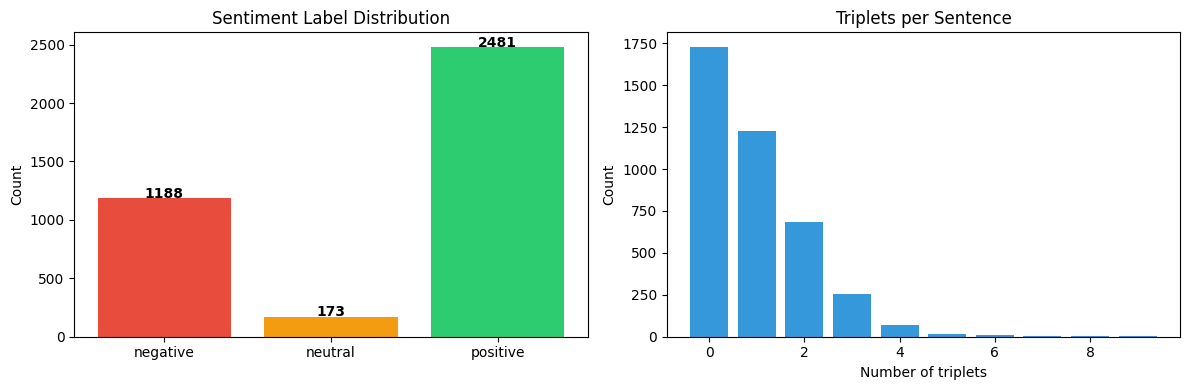

In [5]:
# Phân phối sentiment labels
all_triplets = [t for triplets in df['triplets_parsed'] for t in triplets]
sentiments = [int(t[2]) for t in all_triplets if len(t) >= 3]
sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

sentiment_counts = Counter(sentiments)
print(f'Tổng số triplets: {len(all_triplets)}')
print(f'\nPhân phối sentiment:')
for k, v in sorted(sentiment_counts.items()):
    print(f'  {k} ({sentiment_map.get(k, k)}): {v} ({v/len(sentiments)*100:.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [sentiment_map.get(k, str(k)) for k in sorted(sentiment_counts.keys())]
counts = [sentiment_counts[k] for k in sorted(sentiment_counts.keys())]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(labels, counts, color=colors[:len(labels)])
axes[0].set_title('Sentiment Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

triplet_dist = df['n_triplets'].value_counts().sort_index()
axes[1].bar(triplet_dist.index, triplet_dist.values, color='#3498db')
axes[1].set_title('Triplets per Sentence')
axes[1].set_xlabel('Number of triplets')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
# Top aspect terms
aspects = [t[0].lower().strip() for t in all_triplets if len(t) >= 1]
top_aspects = Counter(aspects).most_common(20)

print('Top 20 aspect terms:')
for aspect, count in top_aspects:
    print(f"  '{aspect}': {count}")

Top 20 aspect terms:
  'game': 155
  'book': 92
  'story': 73
  'app': 62
  'price': 49
  'it': 49
  'quality': 44
  'sound': 40
  'characters': 38
  'sound quality': 25
  'colors': 24
  'value': 22
  'battery': 21
  'color': 21
  'series': 20
  'cable': 19
  'books': 18
  'ink': 18
  'program': 18
  'fit': 17


## Section 2 — Data Preprocessing

Chuyển từ format `(sentence, [triplets])` sang format flat `(sentence, aspect, sentiment)` để huấn luyện.

**Giữ nguyên 3 class:** negative (0), neutral (1), positive (2). Dùng class weight để xử lý imbalance thay vì gộp nhãn.

In [7]:
# Flatten triplets
rows = []
for _, row in df.iterrows():
    for triplet in row['triplets_parsed']:
        if len(triplet) < 3:
            continue
        aspect, opinion, sentiment = triplet[0], triplet[1], triplet[2]
        rows.append({
            'parent_asin': row['parent_asin'],
            'sentence_text': row['sentence_text'],
            'aspect': str(aspect).lower().strip(),
            'opinion': str(opinion).lower().strip(),
            'sentiment': int(sentiment),
        })

df_asc = pd.DataFrame(rows)

# Cũng clean tag trong aspect và opinion
df_asc['aspect'] = df_asc['aspect'].apply(clean_text)
df_asc['opinion'] = df_asc['opinion'].apply(clean_text)

# Giữ nguyên 3 class
label_names = ['negative', 'neutral', 'positive']
num_labels = 3

df_asc['sentiment_label'] = df_asc['sentiment'].map({i: l for i, l in enumerate(label_names)})
df_asc['input_text'] = df_asc['sentence_text'] + ' </s> ' + df_asc['aspect']

print(f'Số rows sau flatten: {len(df_asc)}')
print(f'Số class: {num_labels} — {label_names}')
print(f'\nPhân phối sentiment:')
print(df_asc['sentiment_label'].value_counts())
df_asc.head(5)

Số rows sau flatten: 3842
Số class: 3 — ['negative', 'neutral', 'positive']

Phân phối sentiment:
sentiment_label
positive    2481
negative    1188
neutral      173
Name: count, dtype: int64


,parent_asin,sentence_text,aspect,opinion,sentiment,sentiment_label,input_text
0,B07DGRVTWF,basically a poor implementation of the alexa p...,alexa platform,poor implementation,0,negative,basically a poor implementation of the alexa p...
1,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,great,2,positive,support through direct messaging was great no ...
2,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,no language barrier,2,positive,support through direct messaging was great no ...
3,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,very responsive,2,positive,support through direct messaging was great no ...
4,B00G6SQJ46,i like this ipad cover i like this ipad cover,ipad cover,like,2,positive,i like this ipad cover i like this ipad cover ...


## Section 3 — Train/Test Split (sentence-level)

Split ở mức **câu** trước, sau đó mới flatten từng tập riêng.
Đảm bảo toàn bộ aspects của một câu chỉ nằm trong một tập duy nhất.

In [8]:
from sklearn.model_selection import train_test_split

df_with_triplets = df[df['n_triplets'] > 0].copy()

def majority_sentiment(triplets):
    labels = [int(t[2]) for t in triplets if len(t) >= 3]
    return max(set(labels), key=labels.count) if labels else 2

df_with_triplets['majority_sentiment'] = df_with_triplets['triplets_parsed'].apply(majority_sentiment)

trainval_sents, test_sents = train_test_split(
    df_with_triplets,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=df_with_triplets['majority_sentiment']
)

train_sents, val_sents = train_test_split(
    trainval_sents,
    test_size=0.111,
    random_state=42,
    shuffle=True,
    stratify=trainval_sents['majority_sentiment']
)

print(f'Tổng câu có triplets: {len(df_with_triplets)}')
print(f'  Câu train: {len(train_sents)} | Câu val: {len(val_sents)} | Câu test: {len(test_sents)}')

Tổng câu có triplets: 2271
  Câu train: 1816 | Câu val: 227 | Câu test: 228


In [9]:
def flatten_sentences(df_sents):
    rows = []
    for _, row in df_sents.iterrows():
        for triplet in row['triplets_parsed']:
            if len(triplet) < 3:
                continue
            aspect, opinion, sentiment = triplet[0], triplet[1], int(triplet[2])
            rows.append({
                'parent_asin':   row['parent_asin'],
                'sentence_text': row['sentence_text'],
                'aspect':        clean_text(str(aspect).lower().strip()),
                'opinion':       clean_text(str(opinion).lower().strip()),
                'sentiment':     sentiment,
            })
    result = pd.DataFrame(rows)
    result['sentiment_label'] = result['sentiment'].map({i: l for i, l in enumerate(label_names)})
    result['input_text'] = result['sentence_text'] + ' </s> ' + result['aspect']
    return result

train_df = flatten_sentences(train_sents)
val_df   = flatten_sentences(val_sents)
test_df  = flatten_sentences(test_sents)

print(f'Sau flatten:')
print(f'  Triplets train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}')
print(f'\nPhân phối sentiment trong TRAIN:')
print(train_df['sentiment_label'].value_counts())
print(f'\nPhân phối sentiment trong VAL:')
print(val_df['sentiment_label'].value_counts())
print(f'\nPhân phối sentiment trong TEST:')
print(test_df['sentiment_label'].value_counts())

Sau flatten:
  Triplets train: 3060 | val: 388 | test: 394

Phân phối sentiment trong TRAIN:
sentiment_label
positive    1973
negative     948
neutral      139
Name: count, dtype: int64

Phân phối sentiment trong VAL:
sentiment_label
positive    255
negative    118
neutral      15
Name: count, dtype: int64

Phân phối sentiment trong TEST:
sentiment_label
positive    253
negative    122
neutral      19
Name: count, dtype: int64


In [10]:
import os
os.makedirs('../outputs/reports', exist_ok=True)

train_df.to_parquet('../outputs/asc_roberta_train.parquet', index=False)
test_df.to_parquet('../outputs/asc_roberta_test.parquet', index=False)

In [ ]:
import torch
import numpy as np
from torch import nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

MODEL_NAME = 'roberta-base'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

model = model.float()

print(f'\nLoaded: {MODEL_NAME} (num_labels={num_labels})')

In [12]:
# Tokenize — RoBERTa dùng max_length=128 (BPE tokenizer hiệu quả hơn, câu review thường ngắn)
def tokenize_fn(examples):
    return tokenizer(
        examples['input_text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_dataset = Dataset.from_pandas(train_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))
val_dataset   = Dataset.from_pandas(val_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))
test_dataset  = Dataset.from_pandas(test_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))

train_dataset = train_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])
val_dataset   = val_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])
test_dataset  = test_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])

train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Map:   0%|          | 0/3060 [00:00<?, ? examples/s]

Map:   0%|          | 0/388 [00:00<?, ? examples/s]

Map:   0%|          | 0/394 [00:00<?, ? examples/s]

Train: 3060 | Val: 388 | Test: 394


In [13]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight

# Class weights cho imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(num_labels),
    y=train_df['sentiment'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Class weights: {dict(zip(label_names, class_weights.round(3)))}')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
    }

Class weights: {'negative': np.float64(1.076), 'neutral': np.float64(7.338), 'positive': np.float64(0.517)}


In [14]:
training_args = TrainingArguments(
    output_dir='../outputs/roberta_asc',
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    weight_decay=0.02,
    warmup_ratio=0.06,
    lr_scheduler_type='cosine',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    bf16=False,
    report_to='none',
    save_total_limit=2,
    gradient_accumulation_steps=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.229296,0.895365,0.796392,0.595184
2,1.438829,0.992125,0.824742,0.584339
3,1.265633,0.754935,0.724227,0.590763
4,0.913594,0.774233,0.775773,0.624919


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=192, training_loss=1.4847991652786732, metrics={'train_runtime': 195.7222, 'train_samples_per_second': 62.538, 'train_steps_per_second': 0.981, 'total_flos': 805127058247680.0, 'train_loss': 1.4847991652786732, 'epoch': 4.0})

In [16]:
# Evaluate RoBERTa trên test set
predictions = trainer.predict(test_dataset)
y_pred_roberta = np.argmax(predictions.predictions, axis=-1)
test_df['pred_roberta'] = y_pred_roberta
y_true = test_df['sentiment']

print('RoBERTa:')
print(f'Accuracy: {accuracy_score(y_true, y_pred_roberta):.4f}')
print(classification_report(y_true, y_pred_roberta, target_names=label_names))

RoBERTa:
Accuracy: 0.8376
              precision    recall  f1-score   support

    negative       0.79      0.83      0.81       122
     neutral       0.07      0.11      0.09        19
    positive       0.95      0.90      0.92       253

    accuracy                           0.84       394
   macro avg       0.60      0.61      0.61       394
weighted avg       0.86      0.84      0.85       394

